In [1]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset
from transformers import ASTForAudioClassification
from transformers import DefaultDataCollator
#from datasets import load_metric
import evaluate
from transformers import Trainer, TrainingArguments
import os

c:\Users\Marina\genres\beat_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Marina\genres\beat_venv\Lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: 'Could not find module 'C:\Users\Marina\genres\beat_venv\Lib\site-packages\torchvision\image.pyd' (or one of its dependencies). Try using the full path with constructor syntax.'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
c:\Users\Marina\genres\beat_venv\Lib\site-packages\torchvision\datapoints\__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are s

In [7]:

#spec = np.load("path_to_spec.npy")  # shape: (128, time)
path_spec = Path(r"C:\Polina\master\thesis\beat_this\data\audio\spectograms_npz\gtzan.npz")
data = np.load(path_spec)
lst = data.files
item = "gtzan_blues_00099/track"
# for item in lst:
#     print(item)
spectrogram = data[item].transpose()
#spec = spec[None, :, :]
print(f"spectrogram shape before {spectrogram.shape}")
spec = spectrogram[None, :, :]
print(f"spectrogram shape after {spec.shape}")


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Polina\\master\\thesis\\beat_this\\data\\audio\\spectograms_npz\\gtzan.npz'

In [5]:
path = os.path.join(Path(r"C:\Polina\master\thesis\beat_this\data\audio\spectrograms\gtzan_old\gtzan_blues_00000"), "track.npy")
spec_ex =  np.load(path)

In [ ]:
data = Path(r"C:\Polina\master\thesis\beat_this\data\audio\spectrograms\gtzan_old")
for file in os.listdir(data):
    path_file = os.path.join(data, file, "track.npy")
    print(file[6:][:-6])

In [1]:
spec_example = train_dataset[0]["input_values"]
print(spec_example.shape)
# #print(spec_example.squeeze(0).shape)
# max_time = 1000
# spec_example = le[:, :max_time]
# print(spec_example.shape)

NameError: name 'train_dataset' is not defined

In [38]:
# dataset =[]
# labels = []
# # for file in data:
# #     spectrogram = data[file].transpose()
# #     #spec = spectrogram[None, :, :]
# #     labels.append(file[6:][:-12])
# #     dataset.append(spec)
tracks_path = []
labels = []
data_path = Path(r"C:\Polina\master\thesis\beat_this\data\audio\spectrograms\gtzan_old")
for file in os.listdir(data_path):
    path_file = os.path.join(data, file, "track.npy")
    tracks_path.append(path_file)
    labels.append(file[6:][:-6])
le = LabelEncoder()
encoded_labels = le.fit_transform(labels)
train, validation, train_labels, val_labels = train_test_split(
        tracks_path, encoded_labels, test_size=0.2, stratify=encoded_labels, random_state=42)



In [ ]:
class GTZANSpectrogramDataset(Dataset):
    def __init__(self, paths, labels):
        self.paths = paths
        self.labels = labels
        self.max_time = 1020
        self.target_time_steps = 1214
    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        #spec = self.spectrograms[idx]  # shape: (128, time)
        spec = np.load(self.paths[idx])
        #spec = spec[None, :, :]  # add channel dim
        if spec.ndim == 3 and spec.shape[0] == 1:
            spec = spec.squeeze(0)
        # if spec.shape[1] < self.target_time_steps:
        #     # Pad with zeros if shorter
        #     pad_width = ((0, 0), (0, self.target_time_steps - spec.shape[1]))
        #     spec = np.pad(spec, pad_width, mode='constant')
        # else:
        #     # Truncate if longer
        #     spec = spec[:, :self.target_time_steps]
        spec = spec[:self.max_time, :]
        spec = torch.tensor(spec, dtype=torch.float32)
        
        #spec = spec.unsqueeze(0)
        label = self.labels[idx]
        return {"input_values": spec, "labels": label}

model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=10,  # GTZAN has 10 genres
    ignore_mismatched_sizes=True  # allows adjusting output layer
)

data_collator = DefaultDataCollator()
#metric = load_metric("accuracy")
metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return metric.compute(predictions=predictions, references=labels)
training_args = TrainingArguments(
    output_dir="./ast-gtzan",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=3e-5,
    num_train_epochs=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to=None
)
train_dataset = GTZANSpectrogramDataset(train, train_labels)
val_dataset = GTZANSpectrogramDataset(validation, val_labels)
trainer = Trainer(
    model = model,
    args= training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=None,  # AST doesn't use a tokenizer
    data_collator=data_collator,
    compute_metrics=compute_metrics
)
trainer.train()

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/1000 [00:00<?, ?it/s]

In [31]:
dataset =[]
labels = []
for file in data:
    spectrogram = data[file].transpose()
    spec = spectrogram[None, :, :]
    labels.append(file[6:][:-12])
    dataset.append(spec)
#dataset = np.array(dataset)
#dataset.shape

In [35]:
le = LabelEncoder()
encoded_labels = le.fit_transform(labels)

In [38]:
train, validation, train_labels, val_labels = train_test_split(
        dataset, encoded_labels, test_size=0.2, stratify=encoded_labels, random_state=42)

In [ ]:


class GTZANSpectrogramDataset(Dataset):
    def __init__(self, spectrogram_paths, labels):
        self.paths = spectrogram_paths
        self.labels = labels

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        spec = np.load(self.paths[idx])  # shape: (128, time)
        spec = spec[None, :, :]  # add channel dim
        spec = torch.tensor(spec, dtype=torch.float32)
        label = self.labels[idx]
        return {"pixel_values": spec, "labels": label}

In [ ]:


model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=10,  # GTZAN has 10 genres
    ignore_mismatched_sizes=True  # allows adjusting output layer
)

In [ ]:

data_collator = DefaultDataCollator()
#metric = load_metric("accuracy")
metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return metric.compute(predictions=predictions, references=labels)


In [10]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./ast-gtzan",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=3e-5,
    num_train_epochs=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
)

In [40]:
train_dataset = GTZANSpectrogramDataset(train, train_labels)
val_dataset = GTZANSpectrogramDataset(validation, val_labels)

In [41]:
trainer = Trainer(
    model = model,
    args= training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=None,  # AST doesn't use a tokenizer
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\accelerate\accelerator.py:432: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(


In [ ]:
trainer.train()

# getting embeddings & clustering

## loading data and model

In [10]:
import numpy as np
#data = np.load(r"P:\datasets\beat-this\data\audio\spectograms_npz\gtzan.npz")
data_rwc = np.load(r"rwc_wo_augm.npz")
#data_rwc = np.load(r"p:\datasets\geenres\fma\fma_test_unsorted\audio\spectrograms\fma_test_unsorted.npz")
#data_rwc = np.load(r"c:\Polina\data\rwc_wo_augm.npz")
lst = data_rwc.files
genres = [file.split("_")[1] for file in lst]

In [ ]:
# wo_augm = [file for file in lst if (file.endswith("track") and not file.startswith("rwc_royalty"))]
# genres = [file.split("_")[1] for file in wo_augm]
# rwc_data = {key : data_rwc[key] for key in wo_augm}
# np.savez("rwc_wo_augm.npz", **rwc_data)

In [3]:
# new model (audio data)
from transformers import PreTrainedModel
from transformers.modeling_outputs import SequenceClassifierOutput
import torch.nn as nn
import torch.nn.functional as F
from transformers import PretrainedConfig
from transformers import ASTConfig
from transformers import ASTModel
ast_base = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
class ASTGenreConfig(ASTConfig):
    model_type= "ast-genre_classification"
    def __init__(self, **kwargs):   # **kwargs: arbitrary number of key words arguments
        super().__init__(**kwargs)
        self.num_labels =kwargs.get("num_labels", 10)
        self.dropouts = kwargs.get("dropouts", 0.2)
        self.learning_rate = kwargs.get("learning_rate",3e-5 )
        self.freeze_layers = kwargs.get("freeze_layers", None)
        self.dropout_top = kwargs.get("dropout_top", 0)



class ASTForGenreClassification(PreTrainedModel):
    config_class = ASTGenreConfig

    def __init__(self, config, ast_model=ast_base):
        super().__init__(config)
        self.ast = ast_model
        self.dropout = nn.Dropout(config.dropout_top)
        self.activation_fn = self.get_activation(config.activation_fn)
        self.freeze_layers = config.freeze_layers
        self.classifier = nn.Linear(768, config.num_labels)
        if self.freeze_layers:
            print(f"freezing {self.freeze_layers} layers")
            for i, layer in enumerate(self.ast.encoder.layer):
                if i < self.freeze_layers:
                    for param in layer.parameters():
                        param.requires_grad = False
        

    def get_activation(self, activation_fn) -> nn.Module:
        acrivation_mapping = {
        "relu":  nn.ReLU(),
       # "tanh":  nn.Tanh(),
        "gelu":  nn.GELU(),
        "none":  nn.Identity(),
    }
        return acrivation_mapping.get(activation_fn)
    def get_normalisation(self, norm_type, dim) -> nn.Module:
        norm_mapping = {
        "batch": lambda d: nn.BatchNorm1d(d),
        "layer": lambda d: nn.LayerNorm(d),
        "none": lambda d: nn.Identity(),
    }
        return norm_mapping.get(norm_type, lambda d: nn.Identity())(dim)
    def forward(self, input_values, labels=None):
        x = self.ast.embeddings(input_values)
        x = self.ast.encoder(x).last_hidden_state
        x = x.mean(dim=1)
        x = self.dropout(x)
        x = self.activation_fn(x)
        logits = self.classifier(x)
        assert labels.max() < logits.shape[1], f"Invalid label {labels.max()} for {logits.shape[1]} classes"
        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits, labels, label_smoothing=0.1)
        return SequenceClassifierOutput(loss=loss, logits=logits)

In [ ]:

# new model (audio data)
import numpy as np
import torch

model = ASTForGenreClassification.from_pretrained("PolinaKozarovytska/ast")
model.eval()  # set to evaluation mode


freezing 1 layers


ASTForGenreClassification(
  (ast): ASTModel(
    (embeddings): ASTEmbeddings(
      (patch_embeddings): ASTPatchEmbeddings(
        (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ASTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ASTLayer(
          (attention): ASTAttention(
            (attention): ASTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ASTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ASTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [3]:
from transformers import PreTrainedModel
from transformers.modeling_outputs import SequenceClassifierOutput
import torch.nn as nn
import torch.nn.functional as F
from transformers import PretrainedConfig
from transformers import ASTConfig
from transformers import ASTModel
ast_base = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

class ASTGenreConfig(ASTConfig):
    model_type= "ast-genre_classification"
    def __init__(self, num_labels = 10, **kwargs):
        super().__init__(**kwargs)
        self.num_labels = num_labels
class ASTForGenreClassification(PreTrainedModel):
    config_class = ASTGenreConfig

    def __init__(self, config, ast_model=ast_base):
        super().__init__(config)
        self.ast = ast_model
        self.classifier = nn.Linear(768, config.num_labels)
        self.dropout = nn.Dropout(0.2)

    def forward(self, input_values, labels=None):
        x = self.ast.embeddings(input_values)
        x = self.ast.encoder(x).last_hidden_state
        x = x.mean(dim=1)  # or use x[:, 0, :]
        x = self.dropout(x)
        logits = self.classifier(x)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits, labels, label_smoothing=0.1)

        return SequenceClassifierOutput(loss=loss, logits=logits)

c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\huggingface_hub\file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [4]:

import numpy as np
import torch

model = ASTForGenreClassification.from_pretrained("polinaZaroko/ast_try_again")
model.eval()  # set to evaluation mode


ASTForGenreClassification(
  (ast): ASTModel(
    (embeddings): ASTEmbeddings(
      (patch_embeddings): ASTPatchEmbeddings(
        (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ASTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ASTLayer(
          (attention): ASTAttention(
            (attention): ASTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ASTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ASTIntermediate(
            (dense): Linear(in_features=7

In [5]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                                  Param #
ASTForGenreClassification                               --
├─ASTModel: 1-1                                         --
│    └─ASTEmbeddings: 2-1                               933,888
│    │    └─ASTPatchEmbeddings: 3-1                     197,376
│    │    └─Dropout: 3-2                                --
│    └─ASTEncoder: 2-2                                  --
│    │    └─ModuleList: 3-3                             85,054,464
│    └─LayerNorm: 2-3                                   1,536
├─Dropout: 1-2                                          --
├─GELU: 1-3                                             --
├─Linear: 1-4                                           7,690
Total params: 86,194,954
Trainable params: 79,107,082
Non-trainable params: 7,087,872

In [11]:
from sklearn.model_selection import train_test_split
def prepare_data(data, make_split = False, gtzan= False):
    all_keys = data.files
    X = []
    y = []
    for key in all_keys:
        X.append(data[key])
        if gtzan:
            genre = key[6:][:-6]
        else:
            genre = key.split("/")[0]
        y.append(genre)
    if make_split:
        X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)
        return X_train, X_test, y_train, y_test 
    return X,y
X,y = prepare_data(data_rwc)

In [ ]:
y

['rwc_classical_CD1_01',
 'rwc_classical_CD1_02',
 'rwc_classical_CD1_03',
 'rwc_classical_CD1_04',
 'rwc_classical_CD1_05',
 'rwc_classical_CD1_06',
 'rwc_classical_CD2_01',
 'rwc_classical_CD2_02',
 'rwc_classical_CD2_03',
 'rwc_classical_CD2_04',
 'rwc_classical_CD2_05',
 'rwc_classical_CD3_01',
 'rwc_classical_CD3_02',
 'rwc_classical_CD3_03',
 'rwc_classical_CD3_04',
 'rwc_classical_CD3_05',
 'rwc_classical_CD3_06',
 'rwc_classical_CD3_07',
 'rwc_classical_CD4_01',
 'rwc_classical_CD4_02',
 'rwc_classical_CD4_03',
 'rwc_classical_CD4_04',
 'rwc_classical_CD4_05',
 'rwc_classical_CD4_06',
 'rwc_classical_CD4_07',
 'rwc_classical_CD4_08',
 'rwc_classical_CD4_09',
 'rwc_classical_CD4_10',
 'rwc_classical_CD4_11',
 'rwc_classical_CD4_12',
 'rwc_classical_CD4_13',
 'rwc_classical_CD4_14',
 'rwc_classical_CD4_15',
 'rwc_classical_CD4_16',
 'rwc_classical_CD5_01',
 'rwc_classical_CD5_02',
 'rwc_classical_CD5_03',
 'rwc_classical_CD5_04',
 'rwc_classical_CD5_05',
 'rwc_classical_CD5_06',


: 

In [7]:
from tqdm import tqdm
def get_embeddings(X, y):
    spectrograms = {}
    target_time = 1020
    for i in tqdm(range(len(y))):
        spec = X[i]
        label = y[i]
        if spec.shape[0] > target_time:
            spec = spec[:target_time, :]
        spec = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            patches = model.ast.embeddings(spec)
            outputs = model.ast.encoder(patches, output_hidden_states=True)
            last_hidden = outputs.last_hidden_state  # (1, num_patches, hidden_dim)
            embedding= last_hidden.mean(dim = 1)
            spectrograms[label] = embedding
    return spectrograms
spectrograms = get_embeddings(X,y)

100%|██████████| 211/211 [03:56<00:00,  1.12s/it]


In [8]:
#true_labels = [i[:-6] for i in spectrograms.keys()]   # for gtzan case
true_labels = [i.split("_")[1]  for i in spectrograms.keys()]
#true_labels = genres.copy()
spectrograms_np = torch.stack([v.squeeze(0) for v in spectrograms.values()]).numpy()
spectrograms_np.shape

(211, 768)

## dimensionality reduction + normalization

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
spectrograms_scaled = scaler.fit_transform(spectrograms_np)

In [22]:
from sklearn.decomposition import PCA
reduction = "pca"
pca = PCA(n_components=100)
spectrograms_reduced = pca.fit_transform(spectrograms_scaled)
spectrograms_reduced.shape


(211, 100)

In [25]:
import umap.umap_ as umap   # need to install umap-learn
reduction = "umap"
reducer = umap.UMAP(n_components =100)
spectrograms_reduced = reducer.fit_transform(spectrograms_scaled)
spectrograms_reduced.shape

(211, 100)

In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
true_labels_enc = le.fit_transform(true_labels)
label_names = le.classes_

## clustering

In [26]:
from sklearn.cluster  import KMeans
algorithm = "KMeans"
kmeans = KMeans(n_clusters = 3).fit(spectrograms_reduced)
predicted_labels =kmeans.labels_

In [29]:
from scipy.optimize import linear_sum_assignment

def cluster_accuracy(y_true, y_pred):
    D = max(y_pred.max(), y_true.max()) + 1
    cost_matrix = np.zeros((D, D), dtype=np.int64)
    for i in range(len(y_pred)):
        cost_matrix[y_pred[i], y_true[i]] += 1
    row_ind, col_ind = linear_sum_assignment(cost_matrix.max() - cost_matrix)
    return cost_matrix[row_ind, col_ind].sum() / len(y_pred)

acc = cluster_accuracy(true_labels_enc, predicted_labels)
print(f"{algorithm} Accuracy (after best match) with {reduction}: {acc:.2%}")

HDBSCAN Accuracy (after best match) with umap: 84.36%


In [124]:
from sklearn.cluster import AgglomerativeClustering
algorithm = "Agglomerative"
agglomerative = AgglomerativeClustering(n_clusters=3).fit(spectrograms_reduced)
predicted_labels = agglomerative.labels_

In [ ]:
from sklearn.cluster import DBSCAN
algorithm = "DBSCAN"
dbscan = DBSCAN(eps=5, min_samples=3).fit(spectrograms_reduced)
predicted_labels = dbscan.labels_

In [28]:
from sklearn.cluster import HDBSCAN
algorithm = "HDBSCAN"
hdbscan = HDBSCAN(min_cluster_size =10, max_cluster_size= 120).fit(spectrograms_reduced)
predicted_labels = hdbscan.labels_

In [58]:
# getting soft assignments
import hdbscan
hdbscan_soft = hdbscan.HDBSCAN(min_cluster_size=2, prediction_data=True).fit(spectrograms_reduced)
vector_probs = hdbscan_soft.probabilities_
predicted_labels = hdbscan_soft.labels_

c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [30]:
n_clusters = len(set(predicted_labels)) - (1 if -1 in predicted_labels else 0)
n_noise = list(predicted_labels).count(-1)

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

Number of clusters: 3
Number of noise points: 2


In [ ]:
from pyspark.mllib.clustering import PowerIterationClustering
from sklearn.metrics.pairwise import cosine_similarity
from pyspark import SparkContext
from pyspark.mllib.clustering import PowerIterationClustering
from pyspark.mllib.linalg import Vectors
#similarity_matrix = cosine_similarity(spectrograms_reduced)
sc = SparkContext()
data_rdd = sc.parallelize([(i, Vectors.dense(spectrograms_reduced[i])) for i in range(spectrograms_reduced.shape[0])])
print("data is ready")
model = PowerIterationClustering.train(similarity_matrix, 3, 40)
print("ready")
cluster_assignments = model.assignments.map(lambda x: x.cluster).collect()

print("Cluster assignments:", cluster_assignments)


In [ ]:
from pyspark.mllib.clustering import PowerIterationClustering
from sklearn.metrics.pairwise import cosine_similarity
from pyspark import SparkContext
from pyspark.mllib.clustering import PowerIterationClustering
from pyspark.mllib.linalg import Vectors
#similarity_matrix = cosine_similarity(spectrograms_reduced)
sc = SparkContext()

In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("MyApp") \
    .getOrCreate()

sc = spark.sparkContext

print(sc)

PySparkRuntimeError: [JAVA_GATEWAY_EXITED] Java gateway process exited before sending its port number.

In [123]:
import math
def genCircle(r, n):
    points = []
    for i in range(0, n):
        theta = 2.0 * math.pi * i / n
        points.append((r * math.cos(theta), r * math.sin(theta)))
    return points

def sim(x, y):
    dist2 = (x[0] - y[0]) * (x[0] - y[0]) + (x[1] - y[1]) * (x[1] - y[1])
    return math.exp(-dist2 / 2.0)

r1 = 1.0
n1 = 10
r2 = 4.0
n2 = 40
n = n1 + n2
points = genCircle(r1, n1) + genCircle(r2, n2)
similarities = [(i, j, sim(points[i], points[j])) for i in range(1, n) for j in range(0, i)]
rdd = sc.parallelize(similarities, 2)
model = PowerIterationClustering.train(rdd, 2, 40)
model.k

result = sorted(model.assignments().collect(), key=lambda x: x.id)
result[0].cluster == result[1].cluster == result[2].cluster == result[3].cluster

result[4].cluster == result[5].cluster == result[6].cluster == result[7].cluster

import os, tempfile
path = tempfile.mkdtemp()
model.save(sc, path)
sameModel = PowerIterationClusteringModel.load(sc, path)
sameModel.k

result = sorted(model.assignments().collect(), key=lambda x: x.id)
result[0].cluster == result[1].cluster == result[2].cluster == result[3].cluster

result[4].cluster == result[5].cluster == result[6].cluster == result[7].cluster

from shutil import rmtree
try:
    rmtree(path)
except OSError:
    pass

NameError: name 'sc' is not defined

In [77]:
# trying fuzzy c means
import skfda
from skfda import FData
fuzzy_kmeans = skfda.ml.clustering.FuzzyCMeans(n_clusters = 3, random_state=0)
grid_points = np.linspace(0, 1, spectrograms_reduced.shape[0])  # Functional data grid
fdata = skfda.FDataGrid(data_matrix=spectrograms_reduced.T, grid_points=grid_points)
fuzzy_kmeans.fit(fdata)
membership_matrix = fuzzy_kmeans.cluster_centers_.data_matrix
membership_matrix.shape

(3, 211, 1)

In [ ]:
from sklearn.linear_model import LogisticRegression

(3, 211, 1)

## visualization and evaluation

In [110]:
from sklearn import metrics
from sklearn.metrics import pairwise_distances
import pandas as pd
silhouette = metrics.silhouette_score(spectrograms_reduced, predicted_labels)  # Measures how similar a point is to its own cluster compared to other clusters. (-1, 1)
calinski = metrics.calinski_harabasz_score(spectrograms_reduced, predicted_labels) #Ratio of between-cluster dispersion to within-cluster dispersion, higher is better
davies = metrics.davies_bouldin_score(spectrograms_reduced, predicted_labels)  #Measures average similarity between each cluster and its most similar one, lower is better
evaluation_result  = {algorithm: [silhouette, calinski, davies]}
evaluation_results_df = pd.DataFrame.from_dict(evaluation_result,orient = "index", columns = ["silhouette", "calinski", "davies"])
evaluation_results_df

,silhouette,calinski,davies
KMeans,0.620321,1090.373779,0.593106


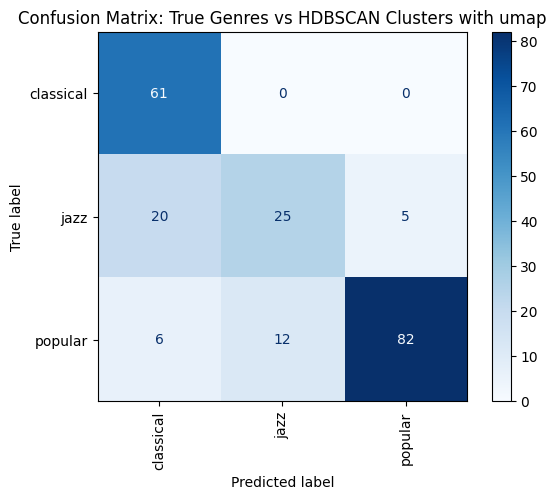

In [32]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from collections import Counter

# Create a dictionary to map clusters to the most frequent genre label in each cluster
cluster_to_label = {}
for cluster in range(kmeans.n_clusters):
    # Get the indices of the samples that belong to the current cluster
    cluster_indices = np.where(kmeans.labels_ == cluster)[0]
    
    # Get the true labels for those samples
    true_labels_for_cluster = true_labels_enc[cluster_indices]
    
    # Find the most frequent true label in the cluster
    most_common_label = Counter(true_labels_for_cluster).most_common(1)[0][0]
    
    # Map the cluster label to the most frequent true label
    cluster_to_label[cluster] = most_common_label

# Create predicted labels that align with true labels based on the cluster-to-label mapping
aligned_predicted_labels = np.array([cluster_to_label[label] for label in kmeans.labels_])

# Create the confusion matrix
cm = confusion_matrix(true_labels_enc, aligned_predicted_labels)

# Create confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(xticks_rotation='vertical', cmap='Blues')

# Set the title and display the plot
plt.title(f"Confusion Matrix: True Genres vs {algorithm} Clusters with {reduction}")
plt.show()


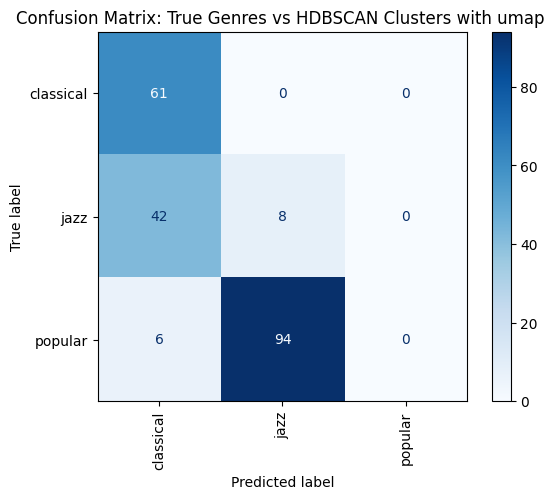

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels_enc, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(xticks_rotation='vertical', cmap='Blues')
plt.title(f"Confusion Matrix: True Genres vs {algorithm} Clusters with {reduction} ")
plt.show()

In [18]:
from scipy.optimize import linear_sum_assignment

def cluster_accuracy(y_true, y_pred):
    D = max(y_pred.max(), y_true.max()) + 1
    cost_matrix = np.zeros((D, D), dtype=np.int64)
    for i in range(len(y_pred)):
        cost_matrix[y_pred[i], y_true[i]] += 1
    row_ind, col_ind = linear_sum_assignment(cost_matrix.max() - cost_matrix)
    return cost_matrix[row_ind, col_ind].sum() / len(y_pred)

acc = cluster_accuracy(true_labels_enc, predicted_labels)
print(f"{algorithm} Accuracy (after best match) with {reduction}: {acc:.2%}")

KMeans Accuracy (after best match) with umap: 78.67%


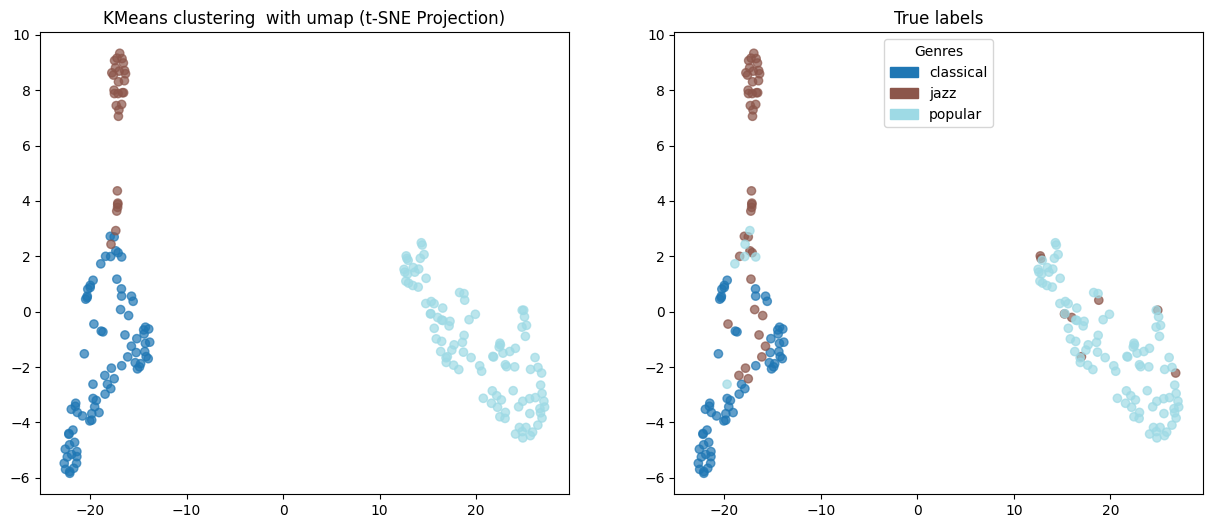

<Figure size 700x600 with 0 Axes>

In [98]:
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches
unique_labels = np.unique(true_labels_enc)
cmap = "tab20"
label2genre = {enc: genre for enc, genre in zip(true_labels_enc, true_labels)}

# Make sure mapping is clean and non-redundant
label2genre = {enc: label2genre[enc] for enc in unique_labels}


X_2d = TSNE(n_components=2, random_state=42).fit_transform(spectrograms_reduced)
fig, axes = plt.subplots(1,2, figsize = (15,6))
plt.figure(figsize=(7, 6))
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=aligned_predicted_labels, cmap=cmap, alpha=0.7)
axes[0].set_title(f"{algorithm} clustering  with {reduction} (t-SNE Projection)")
#plt.show()

#lt.figure(figsize=(6, 6))
#plt.scatter(X_2d[:, 0], X_2d[:, 1], c=true_labels_enc, cmap='tab10', alpha=0.7)
scatter = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=true_labels_enc, cmap=cmap, alpha=0.7)
handles = [
    mpatches.Patch(color=scatter.cmap(scatter.norm(label)), label=label2genre[label])
    for label in unique_labels
]

axes[1].legend(handles=handles,  loc='upper center', title="Genres")
plt.tight_layout()
axes[1].set_title(f"True labels")
plt.show()


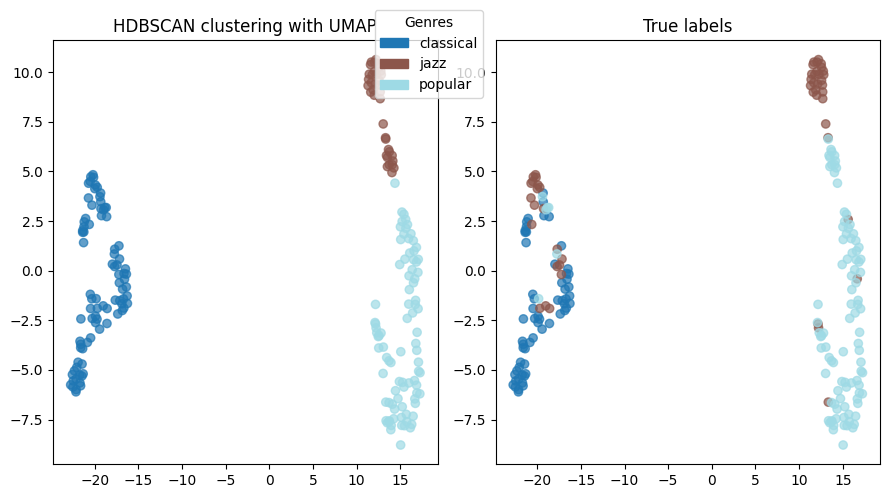

In [33]:
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

unique_labels = np.unique(true_labels_enc)
cmap = "tab20"
label2genre = {enc: genre for enc, genre in zip(true_labels_enc, true_labels)}

# Ensure the mapping is clean and non-redundant
label2genre = {enc: label2genre[enc] for enc in unique_labels}

X_2d = TSNE(n_components=2, random_state=42).fit_transform(spectrograms_reduced)

# Create figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(9,  5))
plt.subplots_adjust(wspace=0.2)  # Adjust space between the plots

# Plot clustering result on the left subplot
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=aligned_predicted_labels, cmap=cmap, alpha=0.7)
axes[0].set_title(f"{algorithm} clustering with UMAP")

# Plot true labels on the right subplot
scatter = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=true_labels_enc, cmap=cmap, alpha=0.7)
handles = [
    mpatches.Patch(color=scatter.cmap(scatter.norm(label)), label=label2genre[label])
    for label in unique_labels
]

# Create a custom legend positioned between the plots
fig.legend(handles=handles,  bbox_to_anchor=(0.1, 0.5, 0.45, 0.5), ncol=1, title="Genres")

axes[1].set_title(f"True labels")

plt.tight_layout()
#plt.savefig("rwc_clustering.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [118]:
import plotly.express as px
import pandas as pd
from sklearn.manifold import TSNE

# Assume you have: 
# - spectrograms_umap (UMAP-reduced features)
# - predicted_labels (cluster labels)
# - file_names (a list with one file name per point)

# Step 1: Reduce dimensions with t-SNE
X_2d = TSNE(n_components=2, random_state=42).fit_transform(spectrograms_reduced)
file_names = data_rwc.files
# Step 2: Create a DataFrame for Plotly
df = pd.DataFrame({
    'x': X_2d[:, 0],
    'y': X_2d[:, 1],
    'label': predicted_labels,
    'file': file_names
})

# Step 3: Plot interactive scatter
fig = px.scatter(
    df,
    x='x', y='y',
    color=df['label'].astype(str),  # Convert to string for discrete colors
    hover_data=['file'],
    title=f"{algorithm} Clustering with {reduction} + t-SNE"
)
fig.update_layout(
    autosize = False,
    width = 800,
    height = 800
)
fig.show()


In [ ]:

data = np.load(r"P:\datasets\geenres\fma\fma_small\fma_small\audio\spectrograms\try.npz")
lst = data.files
print(lst)
#spec = np.load(r"C:\Polina\master\thesis\beat_this\data\audio\spectrograms\gtzan_old\gtzan_rock_00001\track.npy")

#spec = data["smc_193/track"]
spec = data['001039/track']
target_time = 1020
if spec.shape[0] > target_time:
    spec = spec[:target_time, :]
spec = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)
spec.shape


['001039/track', '001039/track_ps-1', '001039/track_ps1', '001039/track_ts-1', '001039/track_ts1', '001039/track_ns1', '001039/track_ns2', '001039/track_ns3', '001039/track_ns4', '001039/track_ns5', '001040/track', '001040/track_ps-1', '001040/track_ps1', '001040/track_ts-1', '001040/track_ts1', '001040/track_ns1', '001040/track_ns2', '001040/track_ns3', '001040/track_ns4', '001040/track_ns5', '001066/track', '001066/track_ps-1', '001066/track_ps1', '001066/track_ts-1', '001066/track_ts1', '001066/track_ns1', '001066/track_ns2', '001066/track_ns3', '001066/track_ns4', '001066/track_ns5']


torch.Size([1, 1020, 128])

# evaluating the model

In [5]:
gtzan_genres = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock"
]
dict_gtzan = {i : genre for i, genre in enumerate(gtzan_genres)}

In [6]:
dict_gtzan

{0: 'blues',
 1: 'classical',
 2: 'country',
 3: 'disco',
 4: 'hiphop',
 5: 'jazz',
 6: 'metal',
 7: 'pop',
 8: 'reggae',
 9: 'rock'}

In [1]:
from transformers import ASTForAudioClassification

model = ASTForAudioClassification.from_pretrained("polinaZaroko/ast-gtzan")
model.eval()  # set to evaluation mode


c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\huggingface_hub\file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


ASTForAudioClassification(
  (audio_spectrogram_transformer): ASTModel(
    (embeddings): ASTEmbeddings(
      (patch_embeddings): ASTPatchEmbeddings(
        (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ASTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ASTLayer(
          (attention): ASTAttention(
            (attention): ASTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ASTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ASTIntermediate(
            (de

In [2]:
#data = np.load(r"C:\Polina\master\thesis\beat_this\data\smc\smc.npz")
import numpy as np
data = np.load(r"P:\datasets\geenres\fma\fma_small\fma_small\audio\spectrograms\fma_001.npz")
lst = data.files
print(lst)

['001039/track', '001039/track_ps-1', '001039/track_ps1', '001039/track_ts-1', '001039/track_ts1', '001040/track', '001040/track_ps-1', '001040/track_ps1', '001040/track_ts-1', '001040/track_ts1', '001066/track', '001066/track_ps-1', '001066/track_ps1', '001066/track_ts-1', '001066/track_ts1', '001069/track', '001069/track_ps-1', '001069/track_ps1', '001069/track_ts-1', '001069/track_ts1', '001073/track', '001073/track_ps-1', '001073/track_ps1', '001073/track_ts-1', '001073/track_ts1', '001075/track', '001075/track_ps-1', '001075/track_ps1', '001075/track_ts-1', '001075/track_ts1', '001082/track', '001082/track_ps-1', '001082/track_ps1', '001082/track_ts-1', '001082/track_ts1', '001083/track', '001083/track_ps-1', '001083/track_ps1', '001083/track_ts-1', '001083/track_ts1', '001087/track', '001087/track_ps-1', '001087/track_ps1', '001087/track_ts-1', '001087/track_ts1', '001102/track', '001102/track_ps-1', '001102/track_ps1', '001102/track_ts-1', '001102/track_ts1', '001193/track', '00

In [26]:
import torch
import numpy as np
#spec = np.load(r"C:\Polina\master\thesis\beat_this\data\audio\spectrograms\gtzan_old\gtzan_rock_00001\track.npy")

#spec = data["smc_193/track"]
spec = data['001925/track']
target_time = 1020
if spec.shape[0] > target_time:
    spec = spec[:target_time, :]
spec = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)
spec.shape


torch.Size([1, 1020, 128])

In [27]:
with torch.no_grad():
    logits = model(input_values = spec).logits
    predicted_id = logits.argmax(dim = -1).item()
#predict_label = model.config
dict_gtzan[predicted_id]


'country'

# Uploading fma dataset to check the model

In [30]:
import pandas as pd
dataset_fma = pd.read_csv(r"C:\Polina\master\thesis\beat_this\data\fma_metadata\tracks.csv")
#dataset_genres = dataset_fma[["track_id"]]
#dataset_fma.head()

C:\Users\polin\AppData\Local\Temp\ipykernel_5796\74948495.py:2: DtypeWarning: Columns (0,1,5,6,21,22,34,38,39,49,55,56,57,58,59) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset_fma = pd.read_csv(r"C:\Polina\master\thesis\beat_this\data\fma_metadata\tracks.csv")


In [4]:
dataset_fma["Unnamed: 0"].values

array([nan, 'track_id', '2', ..., 155318, 155319, 155320],
      shape=(106576,), dtype=object)

In [104]:
dataset_fma.head(10)

,track_id,comments,date_created,date_released,engineer,favorites,id,information,listens,producer,...,publisher,tags,title,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,track_id,comments,date_created,date_released,engineer,favorites,id,information,listens,producer,...,publisher,tags,title,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,[],Food,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,[],Electric Ave,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,[],This World,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10,0,2008-11-26 01:45:08,2008-02-06 00:00:00,NaN,4,6,NaN,47632,NaN,...,NaN,[],Freeway,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,20,0,2008-11-26 01:45:05,2009-01-06 00:00:00,NaN,2,4,"<p> ""spiritual songs"" from Nicky Cook</p>",2710,NaN,...,NaN,[],Spiritual Level,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,26,0,2008-11-26 01:45:05,2009-01-06 00:00:00,NaN,2,4,"<p> ""spiritual songs"" from Nicky Cook</p>",2710,NaN,...,NaN,[],Where is your Love?,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,30,0,2008-11-26 01:45:05,2009-01-06 00:00:00,NaN,2,4,"<p> ""spiritual songs"" from Nicky Cook</p>",2710,NaN,...,NaN,[],Too Happy,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,46,0,2008-11-26 01:45:05,2009-01-06 00:00:00,NaN,2,4,"<p> ""spiritual songs"" from Nicky Cook</p>",2710,NaN,...,NaN,[],Yosemite,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
dataset_fma.columns = dataset_fma.iloc[0]    # fixing the columns and format of the dataset
dataset_fm= dataset_fma[1:]
dataset_fma.reset_index(drop= True, inplace=True)

In [111]:
dataset_genres = dataset_fma[["track_id", "title","genre_top","duration"]]   # picking only important columns

In [113]:
dataset_genres = dataset_genres.drop(1)  # droping NA

In [116]:
dataset_genres.head(10)

,track_id,title,title,genre_top,duration
2,2,AWOL - A Way Of Life,Food,Hip-Hop,168
3,3,AWOL - A Way Of Life,Electric Ave,Hip-Hop,237
4,5,AWOL - A Way Of Life,This World,Hip-Hop,206
5,10,Constant Hitmaker,Freeway,Pop,161
6,20,Niris,Spiritual Level,NaN,311
7,26,Niris,Where is your Love?,NaN,181
8,30,Niris,Too Happy,NaN,174
9,46,Niris,Yosemite,NaN,104
10,48,Niris,Light of Light,NaN,205
11,134,AWOL - A Way Of Life,Street Music,Hip-Hop,207


In [115]:
dataset_genres= dataset_genres[1:]

In [64]:
import os
from pathlib import Path
#all_folders = []
all_tracks = []
path = Path(r"C:\Polina\master\thesis\beat_this\data\fma_small\fma_small")
for file in os.listdir(path):
    #print(file)
    full_path = os.path.join(path, file)
    if os.path.isdir(full_path):
        #all_folders.append(full_path)
        for track in os.listdir(full_path):
            id = int(track[:-4])
            all_tracks.append(id)

In [66]:
len(all_tracks)

8000

In [96]:
dataset_genres["track_id"].values

array([     2,      3,      5, ..., 155318, 155319, 155320],
      shape=(106574,))

In [97]:
filtered_df = dataset_genres[dataset_genres["track_id"].isin(all_tracks)]

In [100]:
filtered_df.isna().sum()

0
track_id      0
title         1
title         5
genre_top     0
duration     48
dtype: int64

In [102]:
filtered_df.to_csv(os.path.join(path, "tracks_small.csv"))

In [120]:
filtered_df["genre_top"].value_counts().to_dict()

{'Instrumental': 1000,
 'Rock': 999,
 'International': 998,
 'Folk': 994,
 'Electronic': 992,
 'Hip-Hop': 989,
 'Experimental': 987,
 'Pop': 986,
 '1': 9,
 '3': 8,
 '4': 6,
 '0': 6,
 '2': 5,
 '5': 5,
 '7': 2,
 '8': 2,
 '305': 1,
 '261': 1,
 '13': 1,
 '11': 1,
 '21': 1,
 '144': 1,
 '12': 1,
 '77': 1,
 '243': 1,
 '6': 1,
 '14': 1,
 '16': 1}

In [94]:
dataset_genres["track_id"] = pd.to_numeric(dataset_genres["track_id"])

In [ ]:
import numpy as np
import pandas as pd
dataset_fma = pd.read_csv(r"P:\datasets\geenres\fma\fma_small\fma_small\tracks_small.csv")

Index(['Unnamed: 0', 'track_id', 'title', 'title.1', 'genre_top', 'duration'], dtype='object')

In [7]:
genres = ['Instrumental',  'Rock', 'International',  'Folk', 'Electronic', 'Hip-Hop', 'Experimental', 'Pop']
dataset_fma_filtered = dataset_fma[dataset_fma["genre_top"].isin( genres)]

In [14]:
dataset_fma_filtered["genre_top"].value_counts().to_dict()

{'Instrumental': 1000,
 'Rock': 999,
 'International': 998,
 'Folk': 994,
 'Electronic': 992,
 'Hip-Hop': 989,
 'Experimental': 987,
 'Pop': 986}

In [12]:
dataset_fma_filtered.to_csv(r"P:\datasets\geenres\fma\fma_small\fma_small\tracks_small_filtered.csv")

In [15]:
dataset_fma_filtered.head(15)

,Unnamed: 0,track_id,title,title.1,genre_top,duration
0,0,2,AWOL - A Way Of Life,Food,Hip-Hop,168
1,1,5,AWOL - A Way Of Life,This World,Hip-Hop,206
2,2,10,Constant Hitmaker,Freeway,Pop,161
3,3,140,The Blind Spot,Queen Of The Wires,Folk,253
4,4,141,Every Man For Himself,Ohio,Folk,182
5,5,148,Contradiction,Blackout 2,Experimental,138
6,6,182,Worn Copy,Jules Lost His Jewels,Rock,228
7,7,190,Blue Piano,Castle Of Stars,Folk,249
8,8,193,Blue Piano,Here With You,Folk,254
9,9,194,Blue Piano,All I want to Do,Folk,192


# dataset file for creating spectrograms from fma


In [19]:
import pandas as pd
dataset_path = pd.read_csv(r"C:\Polina\master\thesis\annotations\dataset_paths.csv")
dataset_path

,fma_000,P:\datasets\geenres\fma\fma_small\fma_small\000


In [2]:
dataset_path_fma = {"title": [], "path": []}

In [3]:
import os
from pathlib import Path
all_folders = []
path_fma = Path(r"P:\datasets\geenres\fma\fma_small\fma_small")
for dir in os.listdir(path_fma):
    dir_path = os.path.join(path_fma, dir)
    if os.path.isdir(dir_path) and dir != "try":
        dataset_path_fma["title"].append("fma_" + str(dir))
        dataset_path_fma["path"].append(dir_path)

In [8]:
import pandas as pd
dataset_path_fma = pd.DataFrame.from_dict(dataset_path_fma)

In [9]:
dataset_path_fma

,title,path
0,fma_000,P:\datasets\geenres\fma\fma_small\fma_small\000
1,fma_001,P:\datasets\geenres\fma\fma_small\fma_small\001
2,fma_002,P:\datasets\geenres\fma\fma_small\fma_small\002
3,fma_003,P:\datasets\geenres\fma\fma_small\fma_small\003
4,fma_004,P:\datasets\geenres\fma\fma_small\fma_small\004
...,...,...
151,fma_151,P:\datasets\geenres\fma\fma_small\fma_small\151
152,fma_152,P:\datasets\geenres\fma\fma_small\fma_small\152
153,fma_153,P:\datasets\geenres\fma\fma_small\fma_small\153
154,fma_154,P:\datasets\geenres\fma\fma_small\fma_small\154


In [11]:
dataset_path_fma.to_csv("dataset_paths_fma.csv", index = False)